### Domain Knowledge: 
* **CCA Variable Grouping & Domain Knowledge**
    * **Group X**: **Physical Brain Metrics** (Predictors)
        * **nWBV** (Normalized Whole Brain Volume): The most critical marker. Measures the actual brain tissue. Decreases (atrophy) as Alzheimer's progresses.
        * **eTIV** (Estimated Total Intracranial Volume): The total space inside the skull. Used as a baseline reference for brain size.
        * **ASF** (Atlas Scaling Factor): A computed scaling factor used to normalize brain scans against a standard template.

    * **Group Y**: Clinical & Cognitive Scores (Outcomes)
        * **MMSE** (Mini-Mental State Exam): A 30-point cognitive test. Scores below 24 indicate potential dementia.
        * **CDR**(Clinical Dementia Rating): A physician’s scale for dementia severity (0 = Healthy, 0.5 = Very Mild, 1 = Mild, 2 = Moderate).
        * **EDUC** (Education): Number of years of education. High education often acts as a "Cognitive Reserve" against symptoms.
        * **SES**(Socioeconomic Status)
        * **Age**: The primary risk factor. Helps differentiate between normal aging and pathological brain shrinkage.
        * **Hand** : prefer hand for the patient

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder , StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA 

In [3]:
data=pd.read_csv(r"oasis_longitudinal.csv")
data.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


* **Metadata** (Excluded from CCA)
    * **Subject/MRI ID**: Unique identifiers (no statistical value).
    * **Group**: The final label (Demented/Non-Demented). Used later for validation, not for the CCtA correlation iself.
    * **Visit / MR Delay** : Order of visiting 
***

In [3]:
# EDA Stage : 
print(data.shape) # 373 Rows , 15 Columns
print(data.describe()) 

(373, 15)
            Visit     MR Delay         Age        EDUC         SES  \
count  373.000000   373.000000  373.000000  373.000000  354.000000   
mean     1.882038   595.104558   77.013405   14.597855    2.460452   
std      0.922843   635.485118    7.640957    2.876339    1.134005   
min      1.000000     0.000000   60.000000    6.000000    1.000000   
25%      1.000000     0.000000   71.000000   12.000000    2.000000   
50%      2.000000   552.000000   77.000000   15.000000    2.000000   
75%      2.000000   873.000000   82.000000   16.000000    3.000000   
max      5.000000  2639.000000   98.000000   23.000000    5.000000   

             MMSE         CDR         eTIV        nWBV         ASF  
count  371.000000  373.000000   373.000000  373.000000  373.000000  
mean    27.342318    0.290885  1488.128686    0.729568    1.195461  
std      3.683244    0.374557   176.139286    0.037135    0.138092  
min      4.000000    0.000000  1106.000000    0.644000    0.876000  
25%     27.000

In [4]:
print(data.info()) # We have 5 Columns are Categorical 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB
None


In [ ]:
print(data.isna().sum()) # SES have 19 nulls , MMSE have 2 nulls
print(data.isna().sum().sum()) # 21 missing value

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64
21
0


In [7]:
print(data.duplicated().sum())

0


In [8]:
# Dealing With this null values using simple imputer to fill this missing value with median : 
print(np.unique(data['SES'])) # Ordinal ==> Replace With Median
print(np.unique(data['MMSE'])) # Intervals or continuouse  ==> Replace With mean 

median_impute=SimpleImputer(strategy='median')
mean_impute=SimpleImputer(strategy='mean')
data['MMSE'] = mean_impute.fit_transform(data[['MMSE']])
data['SES'] = median_impute .fit_transform(data[['SES']])

print(data.isna().sum().sum())

[ 1.  2.  3.  4.  5. nan]
[ 4.  7. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.
 nan]
0


In [9]:
print(np.unique(data['Hand'])) # All hands are R so variance there is 0 , we have to drop this col

['R']


* **"I filtered the dataset to include only the first visit for each subject to ensure independence of observations. This avoids the bias caused by repeated measures from the same patient and transforms the analysis into a Cross-sectional study, which is more appropriate for Canonical Correlation Analysis."** 

In [10]:
# Feature Selection : 
data_new = data[data['Visit'] == 1]
data_new = data_new.drop([ 'Subject ID' , 'MRI ID' , 'Visit' , 'Hand' , 'MR Delay'] , axis =1) 

In [11]:
display(data_new.head())
print(data_new.shape) # Now we have 150 patients 

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
2,Demented,M,75,12,2.0,23.0,0.5,1678,0.736,1.046
5,Nondemented,F,88,18,3.0,28.0,0.0,1215,0.710,1.444
7,Nondemented,M,80,12,4.0,28.0,0.0,1689,0.712,1.039
10,Demented,M,71,16,2.0,28.0,0.5,1357,0.748,1.293


(150, 10)


In [12]:
encoder = LabelEncoder()
data_new['M/F'] = encoder.fit_transform(data_new['M/F'])
data_new.head()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,87,14,2.0,27.0,0.0,1987,0.696,0.883
2,Demented,1,75,12,2.0,23.0,0.5,1678,0.736,1.046
5,Nondemented,0,88,18,3.0,28.0,0.0,1215,0.710,1.444
7,Nondemented,1,80,12,4.0,28.0,0.0,1689,0.712,1.039
10,Demented,1,71,16,2.0,28.0,0.5,1357,0.748,1.293


In [13]:
# Group X: Physical Brain Metric
X_features = ['nWBV', 'eTIV', 'ASF']
X = data_new[X_features]

# Group Y: Clinical & Cognitive Scores
Y_features = ['MMSE', 'CDR', 'Age', 'EDUC', 'SES', 'M/F']
Y = data_new[Y_features]


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

In [14]:
X_final = pd.DataFrame(X_scaled, columns=X_features)
Y_final = pd.DataFrame(Y_scaled, columns=Y_features) 

print(f"X Group Shape: {X_final.shape} (Brain Metrics)")
print(f"Y Group Shape: {Y_final.shape} (Clinical/Demographic)")

X Group Shape: (150, 3) (Brain Metrics)
Y Group Shape: (150, 6) (Clinical/Demographic)


In [15]:
n_components = 2
cca = CCA(n_components = n_components)

cca.fit(X_final, Y_final)
U, V = cca.transform(X_final, Y_final)

In [16]:
canonical_correlations = [np.corrcoef(U[:, i], V[:, i])[0, 1] for i in range(n_components)]

print("Canonical Correlations")
print(f"Pair 1 (p1): {canonical_correlations[0]:.4f} Best Corr")
print(f"Pair 2 (p2): {canonical_correlations[1]:.4f} Second")
print("=================================\n")

Canonical Correlations
Pair 1 (p1): 0.7057 Best Corr
Pair 2 (p2): 0.5830 Second



* **The model successfully bridges the gap between Physical Imaging and Cognitive Performance, proving that a multimodal approach is essential for accurate Alzheimer’s assessment.**

In [17]:
# (Canonical Loadings) 

loadings_X = [np.corrcoef(X_final.iloc[:, i], U[:, 0])[0, 1] for i in range(X_final.shape[1])]
loadings_Y = [np.corrcoef(Y_final.iloc[:, i], V[:, 0])[0, 1] for i in range(Y_final.shape[1])]


df_loadings_X = pd.DataFrame({'Brain_Feature': X_features, 'Loading': loadings_X})
df_loadings_Y = pd.DataFrame({'Clinical_Feature': Y_features, 'Loading': loadings_Y})


df_loadings_X = df_loadings_X.reindex(df_loadings_X['Loading'].abs().sort_values(ascending=False).index)
df_loadings_Y = df_loadings_Y.reindex(df_loadings_Y['Loading'].abs().sort_values(ascending=False).index)

print("Canonical Loadings for Brain Metrics (Set X) ")
print(df_loadings_X.to_string(index=False))
print("\n Canonical Loadings for Clinical Scores (Set Y) ")
print(df_loadings_Y.to_string(index=False))


Canonical Loadings for Brain Metrics (Set X) 
Brain_Feature   Loading
         nWBV  0.942881
         eTIV -0.504141
          ASF  0.485912

 Canonical Loadings for Clinical Scores (Set Y) 
Clinical_Feature   Loading
             Age -0.695717
             M/F -0.570634
            MMSE  0.419044
             CDR -0.402288
             SES  0.153808
            EDUC -0.060323


* **Understanding Canonical LoadingsDefinition**: Canonical Loadings represent the correlation between an **original variable** and its **canonical variate**.
* They indicate the relative importance and contribution of each variable to the discovered pattern.
* **Key Insights from the Results1**.
    * **Set X (Brain Metrics):** The Dominant DrivernWBV (0.94): This is the most critical feature. It shows that Normalized Whole Brain Volume is the primary physical indicator of the brain-clinical relationship
    * eTIV & ASF: These serve as secondary structural scaling factors that refine the model's accuracy regarding head size.2.
    * **Set Y (Clinical & Demographic):** The Clinical ProfileAge (-0.70) & MMSE (0.42): These are the strongest clinical contributors. The model identifies a clear link where brain volume decreases as age increases and memory scores drop.
    * CDR (-0.40): Confirms that lower brain volume correlates with higher dementia severity ratings.Gender (M/F: -0.57): Suggests that gender plays a significant role in how these brain-behavior patterns are distributed in this specific dataset.
3. The "Big Picture" (The Logic)The results demonstrate a strong biological-clinical bridge:Healthy Brain Profile (High nWBV) $\longleftrightarrow$ Healthy Clinical Profile (Younger Age, Higher MMSE, and Lower CDR).

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_35312\1899641315.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loading', y='Brain_Feature', data=df_loadings_X, ax=ax2, palette="Blues_r")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_35312\1899641315.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loading', y='Clinical_Feature', data=df_loadings_Y, ax=ax3, palette="Oranges_r")


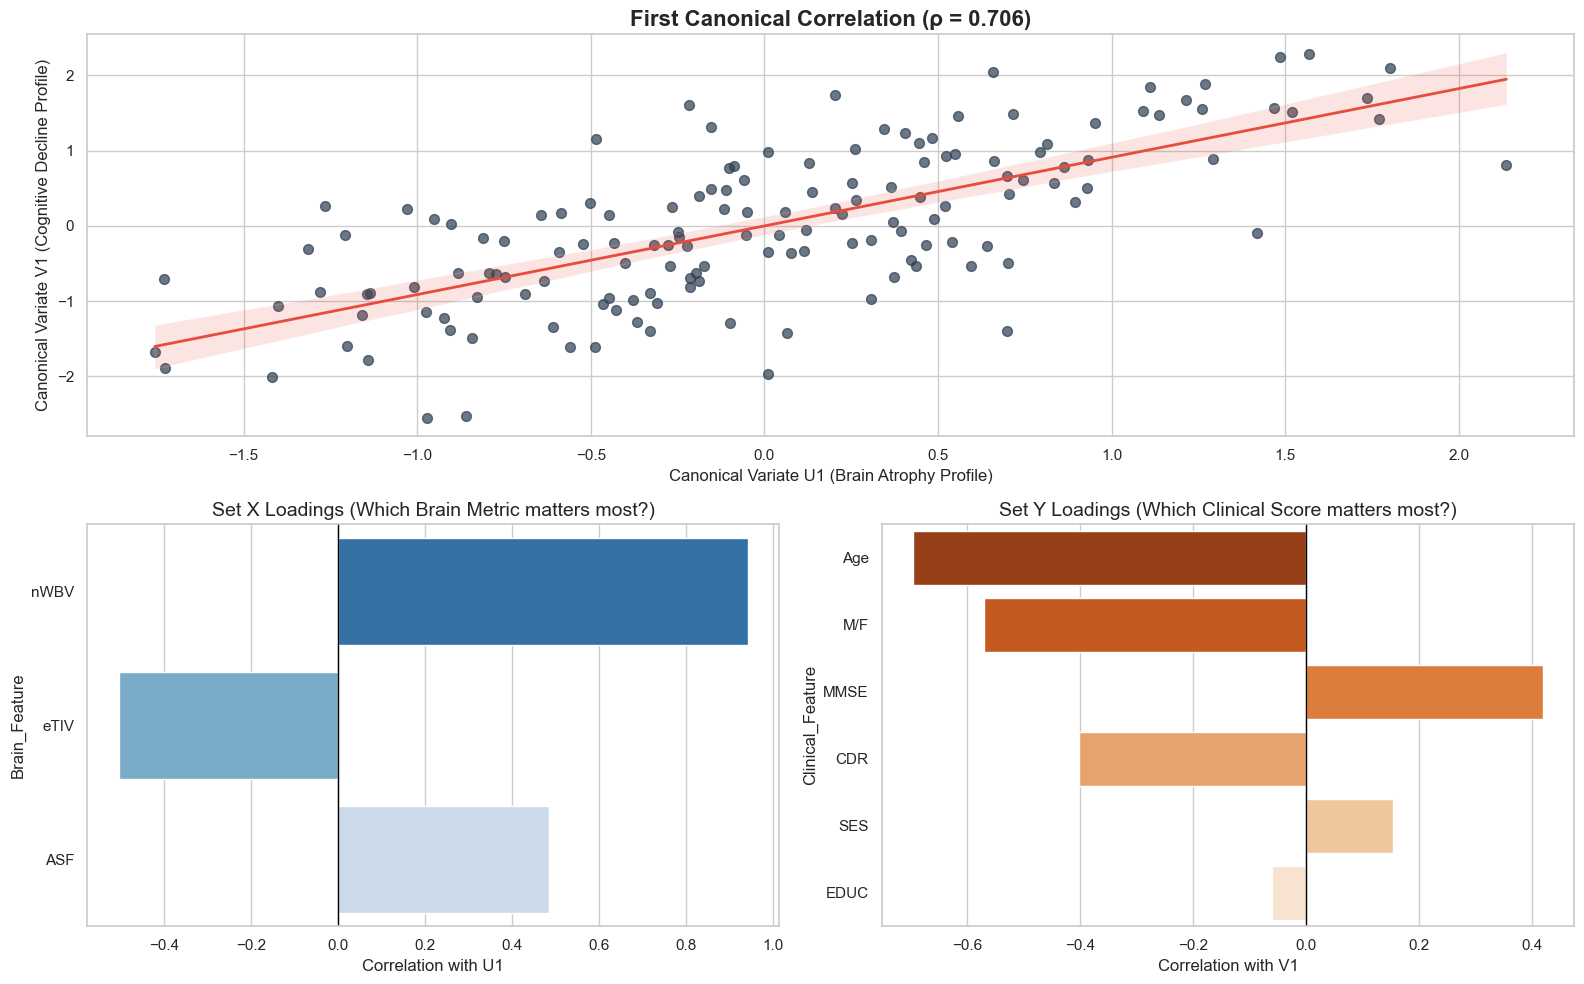

In [18]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 2, (1, 2)) 
sns.regplot(x=U[:, 0], y=V[:, 0], ax=ax1, scatter_kws={'alpha':0.7, 's':50, 'color':'#2c3e50'}, line_kws={'color':'#e74c3c', 'lw':2})
ax1.set_title(f'First Canonical Correlation (ρ = {canonical_correlations[0]:.3f})', fontsize=16, fontweight='bold')
ax1.set_xlabel('Canonical Variate U1 (Brain Atrophy Profile)', fontsize=12)
ax1.set_ylabel('Canonical Variate V1 (Cognitive Decline Profile)', fontsize=12)


ax2 = plt.subplot(2, 2, 3)
sns.barplot(x='Loading', y='Brain_Feature', data=df_loadings_X, ax=ax2, palette="Blues_r")
ax2.set_title('Set X Loadings (Which Brain Metric matters most?)', fontsize=14)
ax2.set_xlabel('Correlation with U1', fontsize=12)
ax2.axvline(0, color='black', linewidth=1)


ax3 = plt.subplot(2, 2, 4)
sns.barplot(x='Loading', y='Clinical_Feature', data=df_loadings_Y, ax=ax3, palette="Oranges_r")
ax3.set_title('Set Y Loadings (Which Clinical Score matters most?)', fontsize=14)
ax3.set_xlabel('Correlation with V1', fontsize=12)
ax3.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()